# Lab 4: 使用 Cellpose 分析真实荧光细胞图像（教师版 v3）


## Task 0：运行环境配置
导入必要模板。如果个别模板没有安装，请自行下载并安装相关函数包。

In [1]:
from importlib import metadata as _metadata
import subprocess as _subprocess
import sys as _sys
from pathlib import Path
import importlib.metadata as metadata
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

In [2]:
import platform
import sys
import time
import torch
from cellpose import io, models, plot

def package_version(name):
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return "not found"

environment = {
    "Python": platform.python_version(),
    "Notebook executable": sys.executable,
    "Cellpose": package_version("cellpose"),
    "PyTorch": torch.__version__,
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "CUDA available": torch.cuda.is_available(),
}
pd.Series(environment, name="environment").to_frame()



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.5 
platform:       	linux 
python version: 	3.10.6 
torch version:  	2.1.1+cu121! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




,environment
Python,3.10.6
Notebook executable,/opt/mamba/bin/python3.10
Cellpose,4.0.5
PyTorch,2.1.1+cu121
NumPy,1.26.2
pandas,2.1.3
CUDA available,True


In [3]:
# 固定随机状态，便于重复课堂演示和后续抽样任务。
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

USE_GPU = torch.cuda.is_available()
DEVICE = torch.cuda.get_device_name(0) if USE_GPU else "CPU"
MODEL_CACHE = Path.home() / ".cellpose" / "models"
cached_models = sorted(p.name for p in MODEL_CACHE.glob("*")) if MODEL_CACHE.exists() else []

# ===== 本实验的数据配置：更换分析对象时只修改这里 =====
DATA_ROOT = Path("/share/image_cloud/lab4/")
cell_line = "Variants0"
field = "field1"
channel = "561-mCherry"

#ORIGINAL_IMAGE_NAME = "average_projection.tif"
SHARPENED_IMAGE_NAME = "average_projection_sharpened_bin4.tif"
MOVIE_NAME = "movie_bin4.bin"

data_dir = DATA_ROOT / cell_line / field / channel
#
image_path = data_dir / SHARPENED_IMAGE_NAME
movie_path = data_dir / MOVIE_NAME

print(f"随机种子: {SEED}")
print(f"推理设备: {DEVICE}")
print(f"Cellpose 模型缓存: {MODEL_CACHE}")
print(f"已发现模型: {cached_models or '未发现；首次运行可能需要下载模型'}")
print(f"当前数据: {cell_line} / {field}")
print(f"数据目录: {data_dir}")


随机种子: 2026
推理设备: Tesla T4
Cellpose 模型缓存: /root/.cellpose/models
已发现模型: 未发现；首次运行可能需要下载模型
当前数据: Variants0 / field1
数据目录: /share/image_cloud/lab4/Variants0/field1/561-mCherry


In [4]:
# 检测GPU；如果GPU可用，Cellpose将使用GPU，否则使用CPU
USE_GPU = torch.cuda.is_available()
DEVICE = torch.cuda.get_device_name(0) if USE_GPU else "CPU"

print(f"Cellpose will run on: {DEVICE}")

model = models.CellposeModel(gpu=USE_GPU)
print("Cellpose 模型初始化完成。")

Cellpose will run on: Tesla T4
/opt/mamba/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Cellpose 模型初始化完成。


## Task 1：认识原始数据并完成一次 Cellpose 分割

### 1.1 认识原始数据

每个实验视野包含一个单通道（黑灰白）荧光视频 `movie_bin4.bin`。压缩后的视频每帧含 **256行 × 512列** 像素，共 **720帧**；相机采样率约为 **196.5967 frame/s**，完整视频时长约为：

$$
T=\frac{720}{196.5967}\approx3.662\text{ s}
$$

视频采用 `.bin` 二进制格式，每个像素以小端序无符号16位整数 `<u2` 保存，即每个像素占2字节，理论取值范围为：

$$
0 \sim 2^{16}-1=65{,}535
$$

Task 1 不直接读取整个视频，而是比较该视野的平均锐化帧：

- `average_projection_sharpened_bin4.tif`：锐化平均帧（边缘更清晰），用于Cellpose的基线分割。


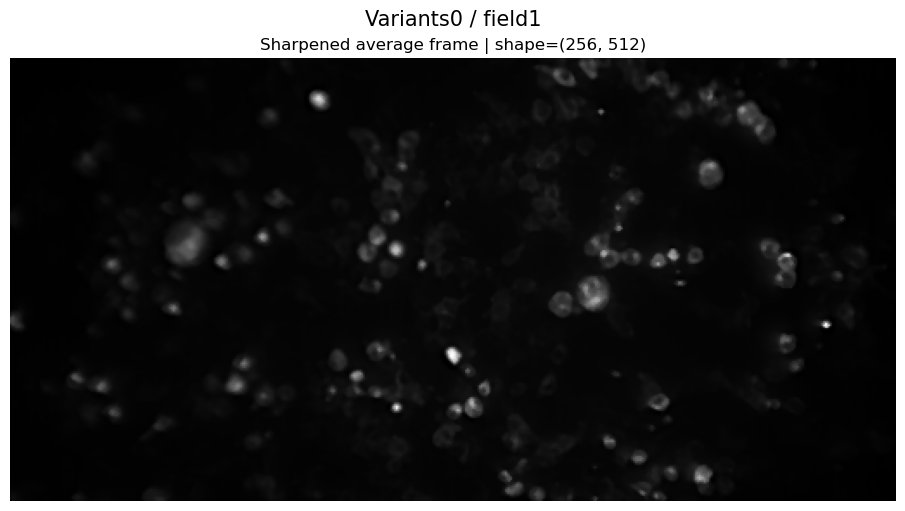

In [5]:
image = io.imread(str(image_path))

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.imshow(image, cmap="gray")
ax.set_title(f"Sharpened average frame | shape={image.shape}")
ax.axis("off")

fig.suptitle(f"{cell_line} / {field}", fontsize=15)
plt.show()

Cellpose input: /share/image_cloud/lab4/Variants0/field1/561-mCherry/average_projection_sharpened_bin4.tif
shape: (256, 512)
dtype: uint16
min: 0
max: 10245
mean: 364.52056884765625
median: 224.0
std: 547.9820556664384


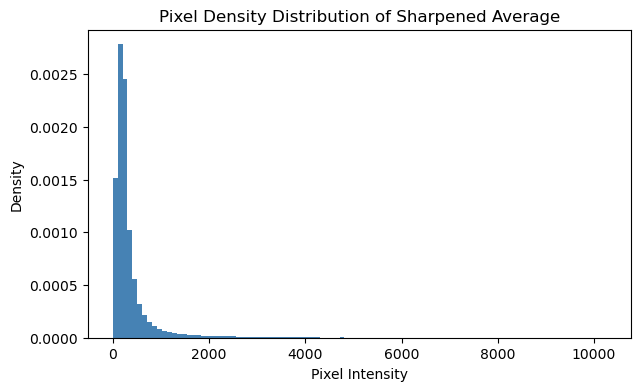

In [6]:
# 后续所有 Cellpose 分析统一使用锐化后的TIFF
print("Cellpose input:", image_path)
print("shape:", image.shape)
print("dtype:", image.dtype)
print("min:", image.min())
print("max:", image.max())
print("mean:", image.mean())
print("median:", np.median(image))
print("std:", image.std())

plt.figure(figsize=(7, 4))
plt.hist(image.ravel(), bins=100, density=True, color="steelblue")
plt.title("Pixel Density Distribution of Sharpened Average")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.show()

锐化平均图与压缩视频具有相同的二维空间尺寸。它整合了720帧中的稳定结构并增强了细胞边缘，因此用于生成一套可应用于整段视频的 Cellpose masks。

### 1.2 锐化平均图 Cellpose 分割

Cellpose-SAM的基本超参数设置、含义和初始值：

- `diameter=None`：指定待分割细胞的典型直径，单位为像素。设置为 `None` 时不人为指定细胞尺度，由 Cellpose-SAM 利用其尺度鲁棒性完成分割。
- `cellprob_threshold=0.0`：细胞概率阈值。降低阈值通常会检出更多或更暗的区域，提高阈值则会使分割更保守。
- `flow_threshold=0.4`：流场误差的最大允许值。降低该值会更严格地删除形状异常的mask，提高该值会保留更多mask。
- `min_size=15`：允许保留的最小mask面积，单位为像素数；面积小于15像素的区域会被删除。

这些是第一次运行的基线，不代表最终最优参数。后续任务会系统比较参数。


In [7]:
CELLPOSE_PARAMS = {
    "diameter": None,
    "cellprob_threshold": 0.0,
    "flow_threshold": 0.4,
    "min_size": 15,
}

start = time.perf_counter()
result = model.eval(image, **CELLPOSE_PARAMS)
elapsed = time.perf_counter() - start

# Cellpose 4通常返回3项；兼容部分旧版API可能返回4项。
if len(result) == 3:
    masks, flows, styles = result
    estimated_diameter = None
elif len(result) == 4:
    masks, flows, styles, estimated_diameter = result
else:
    raise RuntimeError(f"未知的 Cellpose 返回格式：{len(result)} 项")

cell_count = int(masks.max())
areas = np.bincount(masks.ravel())[1:]

print(f"Detected cells: {cell_count}")
print(f"Inference time: {elapsed:.2f} s on {DEVICE}")

if areas.size:
    print(f"Mask area median: {np.median(areas):.1f} pixels")
    print(f"Mask area range: {areas.min()}–{areas.max()} pixels")

Detected cells: 155
Inference time: 2.45 s on Tesla T4
Mask area median: 85.0 pixels
Mask area range: 19–315 pixels


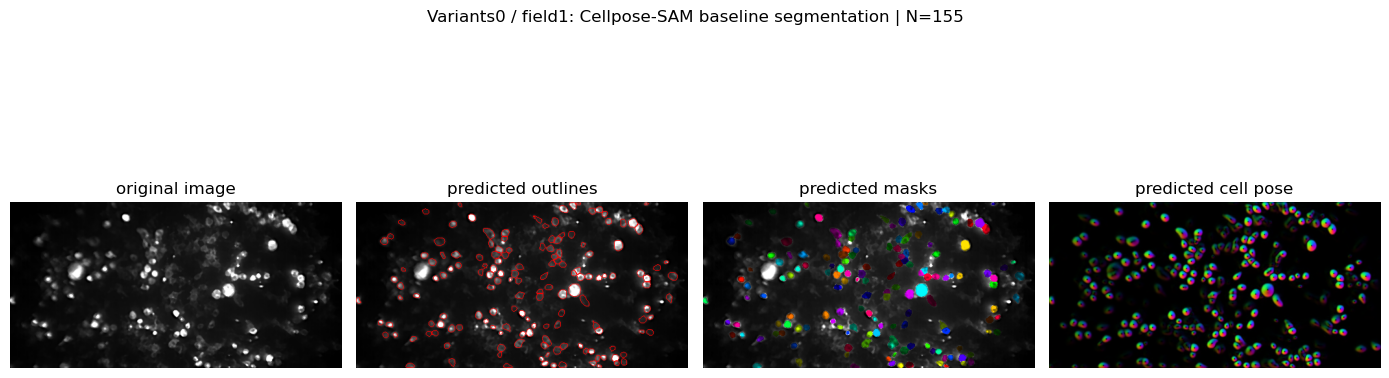

In [8]:
fig = plt.figure(figsize=(14, 5))

plot.show_segmentation(fig, image, masks, flows[0])

fig.suptitle(
    f"{cell_line} / {field}: Cellpose-SAM baseline segmentation | N={cell_count}",
    y=1.02,
)

plt.tight_layout()
plt.show()


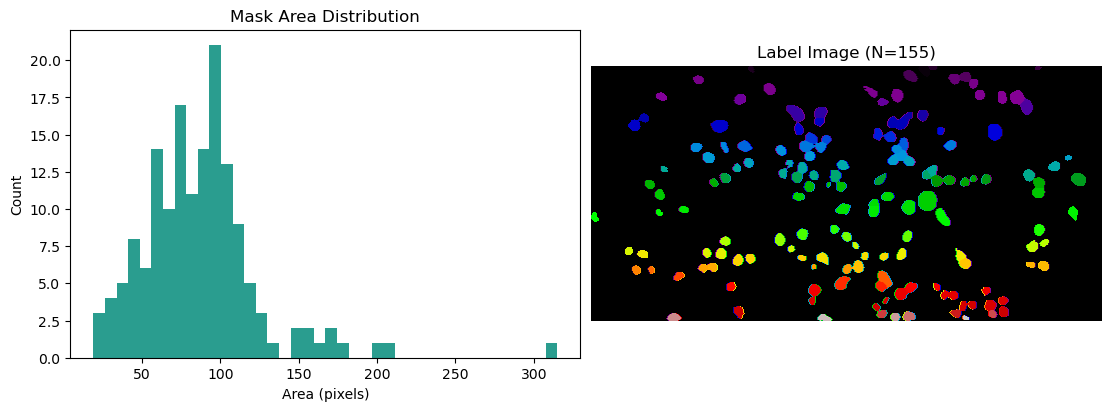

In [9]:
fig, axes = plt.subplots( 1, 2, figsize=(11, 4),constrained_layout=True)
axes[0].hist(areas, bins=40, color="#2A9D8F")
axes[0].set(title="Mask Area Distribution", xlabel="Area (pixels)", ylabel="Count")

axes[1].imshow(masks, cmap="nipy_spectral")
axes[1].set_title(f"Label Image (N={cell_count})")
axes[1].axis("off")

plt.show()

### 1.3 **<font color="green"> TODO：分组研究 Cellpose 超参数 </font>**<br>

1. 观察基线结果: 观察刚刚完成的 Cellpose 基线分割，记录并讨论：

- 默认参数检测到多少个mask？mask面积分布是否合理？
- 哪些位置存在明显的漏检、暗区假阳性、细胞粘连或细胞碎裂？
- 根据基线结果，你认为哪个超参数最值得优先调整？为什么？

2. 分组进行单变量参数实验

全班同学分为三组，所有组使用Variants0/field1同一张锐化平均图。每组只改变指定的一个参数，其余参数保持基线值不变。
建议根据上皮细胞的物理尺寸和像素的关系预设`diameter`=15，并完成以下三组参数效应研究。

| 小组 | 研究参数 | 建议比较的参数值 | 主要观察内容 |
|---|---|---|---|
| 第1组 | `cellprob_threshold` | -2.0、0.0、2.0 | 弱细胞的检出数量与暗区假阳性之间的变化 |
| 第2组 | `flow_threshold` | 0.2、0.4、0.8 | 流场质量控制的严格程度及形状异常mask的保留情况 |
| 第3组 | `min_size` | 15、100、200 | 小mask和噪点被删除的程度，以及真实小细胞是否被误删 |

> **控制量原则**：研究某个参数时，其他量个参数必须保持基线值不变，否则无法判断结果变化由哪个参数引起。

**3. 记录和汇报结果**，每组对每个参数值记录以下结果：

| 参数值 | 检测mask数 | mask面积中位数 | 漏检 | 假阳性 | 粘连 | 碎裂 | 运行时间 |
|---:|---:|---:|---|---|---|---|---:|
|  |  |  |  |  |  |  |  |
|  |  |  |  |  |  |  |  |

其中漏检、假阳性、粘连和碎裂可使用“少 / 中 / 多”进行定性记录。每组选择一组推荐参数，展示对应分割图，并用2–3句话说明选择依据。最后由全班比较四个参数对结果的不同影响。

#### 1.3.1 min_size 调整探究
只改变指定的参数，其余参数保持基线值不变，

比较的参数值：15 50 100 200，
对每个参数值，按照task1.2的格式输出分割后的图片

min_size = 15
Detected cells: 155
Inference time: 1.92 s on Tesla T4
Mask area median: 85.0 pixels
Mask area range: 19–315 pixels


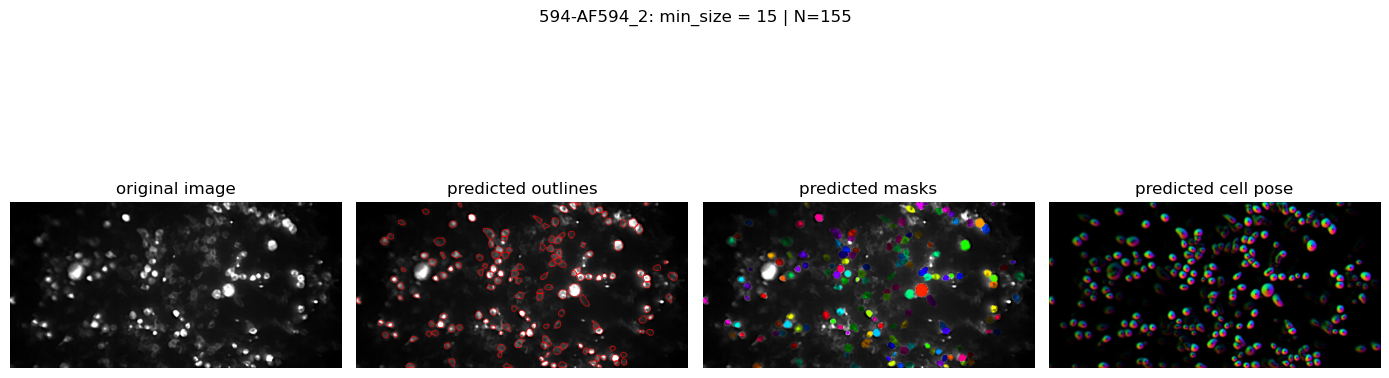

min_size = 50
Detected cells: 121
Inference time: 1.92 s on Tesla T4
Mask area median: 90.0 pixels
Mask area range: 50–315 pixels


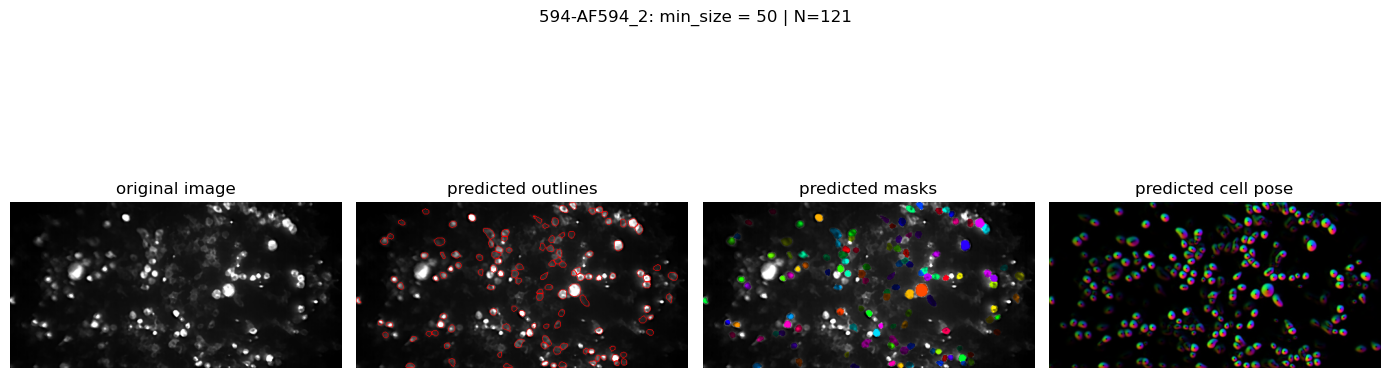

min_size = 100
Detected cells: 15
Inference time: 1.92 s on Tesla T4
Mask area median: 130.0 pixels
Mask area range: 103–206 pixels


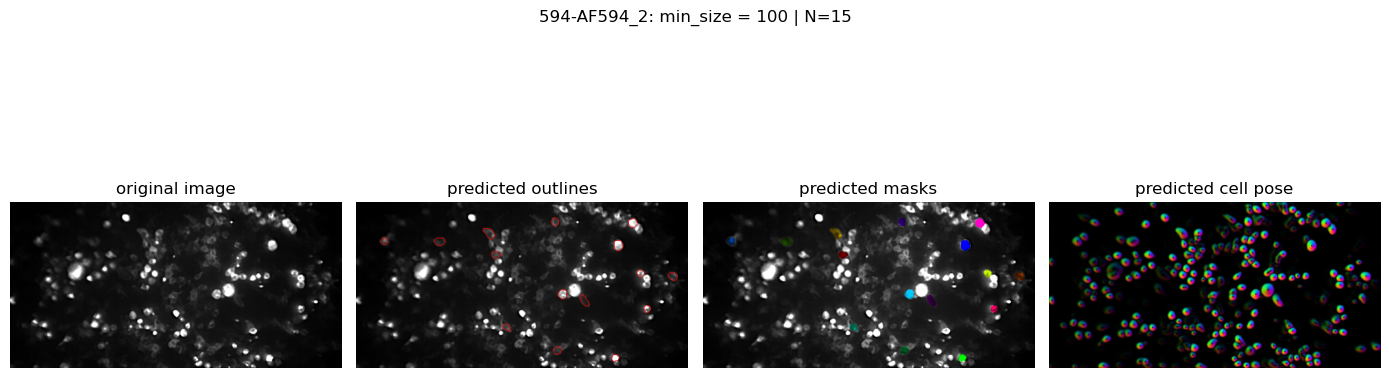

min_size = 200
Detected cells: 0
Inference time: 1.92 s on Tesla T4


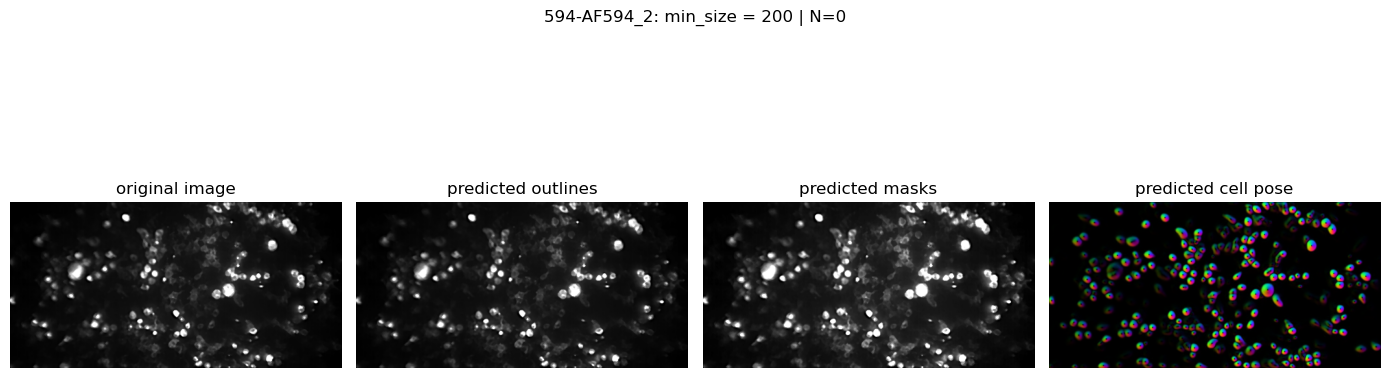

,min_size,cell_count,median_area,runtime_s
0,15,155,85.0,1.919462
1,50,121,90.0,1.924730
2,100,15,130.0,1.924171
3,200,0,NaN,1.919755


In [10]:
MIN_SIZE_VALUES = [15, 50, 100, 200]
BASE_CELLPOSE_PARAMS = {
    "diameter": None,
    "cellprob_threshold": 0.0,
    "flow_threshold": 0.4,
}

min_size_reports = []
for min_size in MIN_SIZE_VALUES:
    params = dict(BASE_CELLPOSE_PARAMS)
    params["min_size"] = min_size

    start = time.perf_counter()
    result = model.eval(image, **params)
    elapsed = time.perf_counter() - start

    if len(result) == 3:
        masks_test, flows_test, styles_test = result
    elif len(result) == 4:
        masks_test, flows_test, styles_test, _ = result
    else:
        raise RuntimeError(f"未知的 Cellpose 返回格式：{len(result)} 项")

    cell_count_test = int(masks_test.max())
    areas_test = np.bincount(masks_test.ravel())[1:]
    median_area = float(np.median(areas_test)) if areas_test.size else float("nan")

    print(f"min_size = {min_size}")
    print(f"Detected cells: {cell_count_test}")
    print(f"Inference time: {elapsed:.2f} s on {DEVICE}")
    if areas_test.size:
        print(f"Mask area median: {median_area:.1f} pixels")
        print(f"Mask area range: {areas_test.min()}–{areas_test.max()} pixels")

    fig = plt.figure(figsize=(14, 5))
    plot.show_segmentation(fig, image, masks_test, flows_test[0])
    fig.suptitle(
        f"594-AF594_2: min_size = {min_size} | N={cell_count_test}",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    min_size_reports.append({
        "min_size": min_size,
        "cell_count": cell_count_test,
        "median_area": median_area,
        "runtime_s": elapsed,
    })

pd.DataFrame(min_size_reports)


## Task 2：提取并分析细胞荧光信号

Task 1已经使用 Cellpose 在锐化平均图上为每个细胞生成了一个mask。用优化后的参数完成最终分割后，下面把同一套masks应用到对应的 `movie_bin4.bin` 的每一帧，获得每个细胞随时间变化的平均荧光强度。随后为每个细胞建立局部背景、校正背景变化，并计算细胞对电刺激的响应。


### 2.1 读取视频的有效帧

`np.memmap`不会立即把整个视频复制到内存，而是仅在需要时读取相应的帧，适合处理较大的`movie_bin4.bin`文件。

In [11]:
from scipy.ndimage import distance_transform_edt, uniform_filter1d
from scipy.signal import butter, find_peaks, sosfiltfilt

FPS = 196.5967
N_ROWS, N_COLS, TOTAL_FRAMES = 256, 512, 720
FRAME_START = 30       # Python从0计数，对应MATLAB第31帧
FRAME_STOP = 630       # 不包含第630帧，共分析600帧

raw_movie = np.memmap(movie_path, dtype="<u2", mode="r")
expected_pixels = TOTAL_FRAMES * N_ROWS * N_COLS
assert raw_movie.size == expected_pixels, (
    f"视频像素数为{raw_movie.size}，预期为{expected_pixels}；请检查文件和movie shape。"
)

# 与MATLAB reshape(movie, 256, 512, 720)保持相同的列优先读取方向。
movie = raw_movie.reshape(TOTAL_FRAMES, N_COLS, N_ROWS).transpose(0, 2, 1)
analysis_movie = movie[FRAME_START:FRAME_STOP]
time_axis = np.arange(analysis_movie.shape[0]) / FPS

assert movie.shape == (TOTAL_FRAMES, N_ROWS, N_COLS)
assert image.shape == movie.shape[1:]

print("movie path:", movie_path)
print("movie shape:", movie.shape)
print("analysis movie shape:", analysis_movie.shape)
print(f"analysis duration: {analysis_movie.shape[0] / FPS:.3f} s")


movie path: /share/image_cloud/lab4/Variants0/field1/561-mCherry/movie_bin4.bin
movie shape: (720, 256, 512)
analysis movie shape: (600, 256, 512)
analysis duration: 3.052 s


### 2.2 提取每个细胞的荧光轨迹

对于每个细胞mask，在每一帧中计算mask覆盖像素的平均值。这样，每个二维细胞区域会转化成一条随时间变化的一维荧光轨迹。

In [12]:
def extract_mean_traces(movie_view, region_masks, chunk_size=25):
    """分批计算多个区域在每一帧中的平均像素值。"""
    weights = region_masks.reshape(len(region_masks), -1).astype(np.float32)
    pixel_counts = weights.sum(axis=1)
    if np.any(pixel_counts == 0):
        raise ValueError("存在不包含像素的空区域。")
    weights /= pixel_counts[:, None]

    traces = np.empty((len(movie_view), len(region_masks)), dtype=np.float32)
    for start in range(0, len(movie_view), chunk_size):
        stop = min(start + chunk_size, len(movie_view))
        frames = np.asarray(movie_view[start:stop], dtype=np.float32)
        traces[start:stop] = frames.reshape(stop - start, -1) @ weights.T
    return traces

cell_ids = np.arange(1, int(masks.max()) + 1)
roi_masks = np.stack([masks == cell_id for cell_id in cell_ids])
cell_areas = roi_masks.sum(axis=(1, 2))
cell_traces = extract_mean_traces(analysis_movie, roi_masks)

print("cell traces shape:", cell_traces.shape)
print("number of cells:", len(cell_ids))

cell traces shape: (600, 155)
number of cells: 155


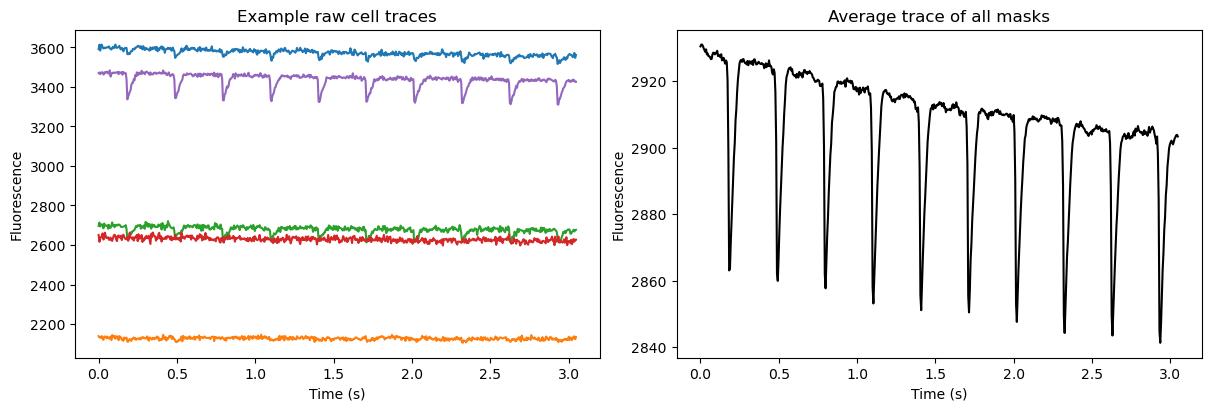

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(time_axis, cell_traces[:, :min(5, len(cell_ids))])
axes[0].set(title="Example raw cell traces", xlabel="Time (s)", ylabel="Fluorescence")
axes[1].plot(time_axis, cell_traces.mean(axis=1), color="black")
axes[1].set(title="Average trace of all masks", xlabel="Time (s)", ylabel="Fluorescence")
plt.show()

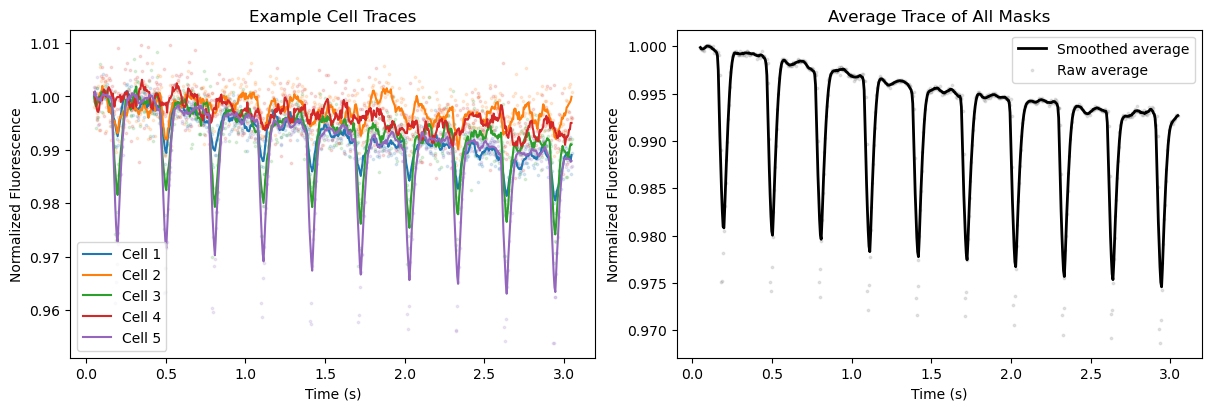

In [14]:
from scipy.ndimage import uniform_filter1d

# 跳过开头10帧的采集瞬态，并选择前5个细胞作为示例
display_start = 10
example_cells = range(min(5, cell_traces.shape[1]))

# 每个细胞分别除以其前30帧的平均亮度
baseline = cell_traces[:30].mean(axis=0)
normalized_traces = cell_traces / baseline

# 7帧移动平均：减少逐帧抖动，同时保留刺激响应
smoothed_traces = uniform_filter1d(
    normalized_traces,
    size=7,
    axis=0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# 左图：示例细胞
for cell in example_cells:
    axes[0].scatter(
        time_axis[display_start:],
        normalized_traces[display_start:, cell],
        s=3,
        alpha=0.15
    )
    axes[0].plot(
        time_axis[display_start:],
        smoothed_traces[display_start:, cell],
        linewidth=1.5,
        label=f"Cell {cell + 1}"
    )

axes[0].set(
    title="Example Cell Traces",
    xlabel="Time (s)",
    ylabel="Normalized Fluorescence"
)
axes[0].legend()

# 右图：所有细胞的平均轨迹
average_trace = normalized_traces.mean(axis=1)
average_smoothed = uniform_filter1d(average_trace, size=7)

axes[1].scatter(
    time_axis[display_start:],
    average_trace[display_start:],
    s=3,
    color="gray",
    alpha=0.2,
    label="Raw average"
)
axes[1].plot(
    time_axis[display_start:],
    average_smoothed[display_start:],
    color="black",
    linewidth=2,
    label="Smoothed average"
)

axes[1].set(
    title="Average Trace of All Masks",
    xlabel="Time (s)",
    ylabel="Normalized Fluorescence"
)
axes[1].legend()

plt.show()

### 2.3 为每个细胞建立局部背景

细胞周围的背景亮度也可能随时间变化。我们先排除所有细胞附近的像素，得到可用的全局背景；再从每个细胞周围一定范围内选择背景像素，作为该细胞的局部背景。

由于新版图像的行、列尺寸均为原高分辨率图像的一半，线性距离参数也相应缩小为原设置的一半。


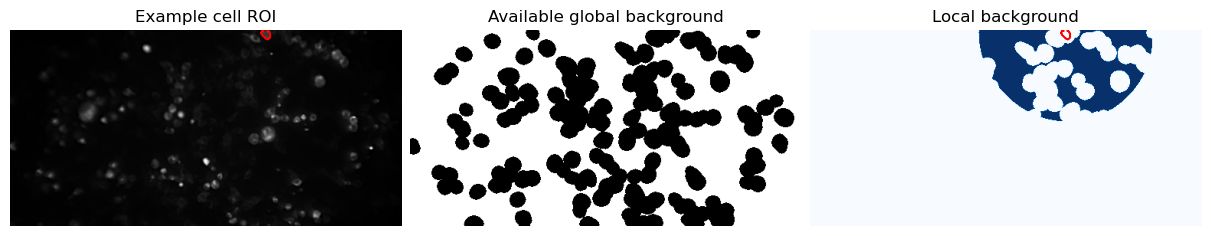

In [15]:
CELL_EXCLUSION_DISTANCE = 6   # 与所有细胞至少相距6像素
LOCAL_BACKGROUND_RADIUS = 108  # 每个细胞周围的局部背景搜索范围

distance_from_any_cell = distance_transform_edt(masks == 0)
global_background = distance_from_any_cell > CELL_EXCLUSION_DISTANCE

local_background_masks = np.empty_like(roi_masks)
for i, roi_mask in enumerate(roi_masks):
    distance_from_cell = distance_transform_edt(~roi_mask)
    local_background_masks[i] = (
        global_background & (distance_from_cell <= LOCAL_BACKGROUND_RADIUS)
    )

background_traces = extract_mean_traces(analysis_movie, local_background_masks)

example_cell = 0
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
axes[0].imshow(image, cmap="gray")
axes[0].contour(roi_masks[example_cell], colors="red", linewidths=0.8)
axes[0].set_title("Example cell ROI")
axes[1].imshow(global_background, cmap="gray")
axes[1].set_title("Available global background")
axes[2].imshow(local_background_masks[example_cell], cmap="Blues")
axes[2].contour(roi_masks[example_cell], colors="red", linewidths=0.8)
axes[2].set_title("Local background")
for ax in axes:
    ax.axis("off")
plt.show()

### 2.4 背景滤波、背景扣除与信号标准化

场刺激频率约为3.28 Hz，背景中可能残留同频变化。先对局部背景使用2.5–3.5 Hz带阻滤波，再使用181帧的移动平均窗口平滑背景。随后从细胞轨迹中扣除背景，并使用刺激前30帧的平均值作为基线进行标准化：

$$F_{norm}(t)=\frac{F_{cell}(t)-F_{background}(t)}{F_0}$$

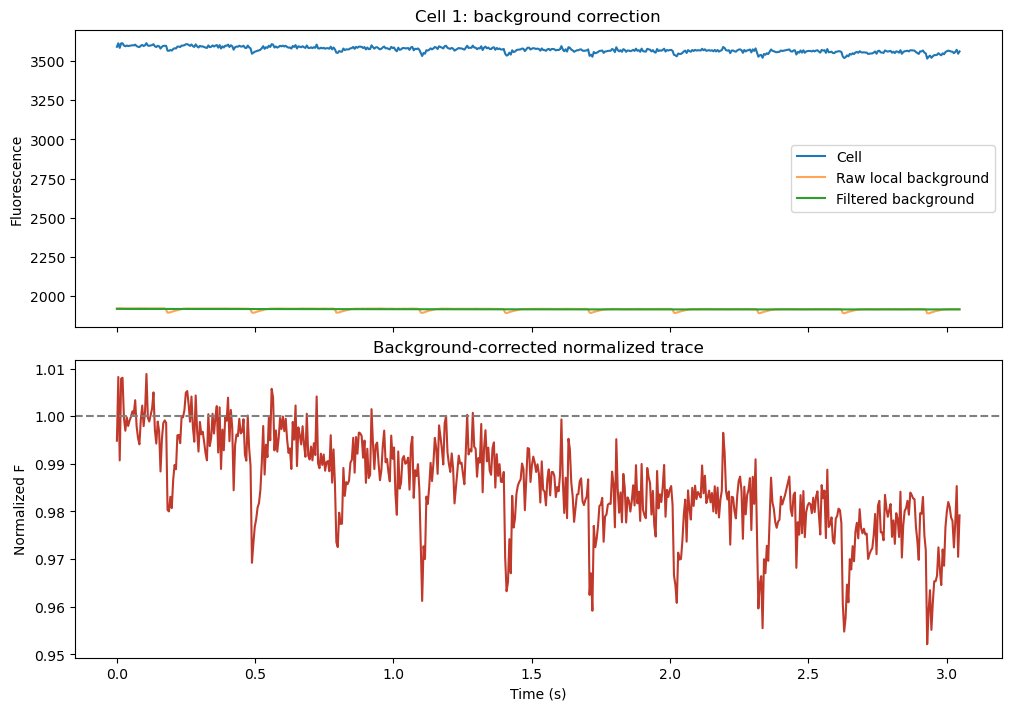

In [16]:
NOTCH_RANGE = (2.5, 3.5)
SMOOTH_WINDOW = 181
BASELINE_FRAMES = 30

sos = butter(2, NOTCH_RANGE, btype="bandstop", fs=FPS, output="sos")
background_notched = sosfiltfilt(sos, background_traces, axis=0)
background_filtered = uniform_filter1d(
    background_notched, size=SMOOTH_WINDOW, axis=0, mode="nearest"
)

cell_corrected = cell_traces - background_filtered
baseline = cell_corrected[:BASELINE_FRAMES].mean(axis=0)
cell_normalized = cell_corrected / baseline

example_cell = 0
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
axes[0].plot(time_axis, cell_traces[:, example_cell], label="Cell")
axes[0].plot(time_axis, background_traces[:, example_cell], label="Raw local background", alpha=0.7)
axes[0].plot(time_axis, background_filtered[:, example_cell], label="Filtered background")
axes[0].set(ylabel="Fluorescence", title=f"Cell {cell_ids[example_cell]}: background correction")
axes[0].legend()
axes[1].plot(time_axis, cell_normalized[:, example_cell], color="#C0392B")
axes[1].axhline(1, color="gray", linestyle="--")
axes[1].set(xlabel="Time (s)", ylabel="Normalized F", title="Background-corrected normalized trace")
plt.show()

### 2.5 检测刺激事件

本实验中的GEVI在受到刺激时荧光下降，因此对所有合格细胞的平均轨迹取反后寻找峰。峰之间的最小距离用于避免把同一次响应重复识别为多个事件。

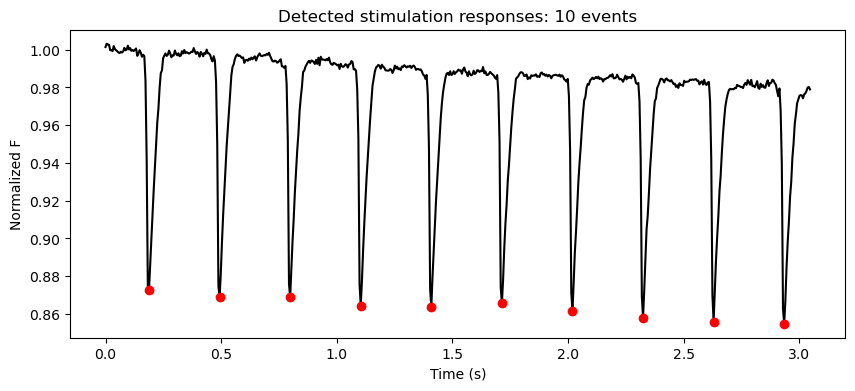

peak frames: [ 67 127 187 247 307 367 427 487 547 607]
peak times in analysis window (s): [0.188 0.493 0.799 1.104 1.409 1.714 2.019 2.325 2.63  2.935]


In [17]:
MIN_CELL_AREA = 15
MIN_PEAK_PROMINENCE = 0.025
MIN_PEAK_DISTANCE = 15

quality_mask = (cell_areas >= MIN_CELL_AREA) & np.isfinite(baseline) & (baseline > 0)
global_trace = cell_normalized[:, quality_mask].mean(axis=1)
peak_signal = uniform_filter1d(1 - global_trace, size=3)
peak_indices, peak_properties = find_peaks(
    peak_signal, prominence=MIN_PEAK_PROMINENCE, distance=MIN_PEAK_DISTANCE
)

plt.figure(figsize=(10, 4))
plt.plot(time_axis, global_trace, color="black")
plt.scatter(time_axis[peak_indices], global_trace[peak_indices], color="red", zorder=3)
plt.xlabel("Time (s)")
plt.ylabel("Normalized F")
plt.title(f"Detected stimulation responses: {len(peak_indices)} events")
plt.show()

print("peak frames:", peak_indices + FRAME_START)
print("peak times in analysis window (s):", np.round(time_axis[peak_indices], 3))

### 2.6 计算单细胞灵敏度

对每个刺激事件，在峰位置前后10帧的窗口内寻找每个细胞的最低荧光值。由于刺激后荧光下降，本实验将单次响应定义为：

$$Sensitivity=1-\min(F_{norm})$$

该值越大，表示细胞对刺激的荧光响应越强。最后排除明显偏离该细胞其余响应的事件，并计算每个细胞的平均灵敏度。

,cell_id,area_pixels,baseline_brightness,sensitivity,response_std,valid_events,pass_basic_qc
0,1,97,1681.313363,0.039051,0.006294,9,True
1,2,35,333.377884,0.065150,0.002764,7,True
2,3,31,779.401953,0.098950,0.005760,9,True
3,4,22,840.014354,0.033831,0.006551,9,True
4,5,127,1550.992045,0.093002,0.003942,8,True


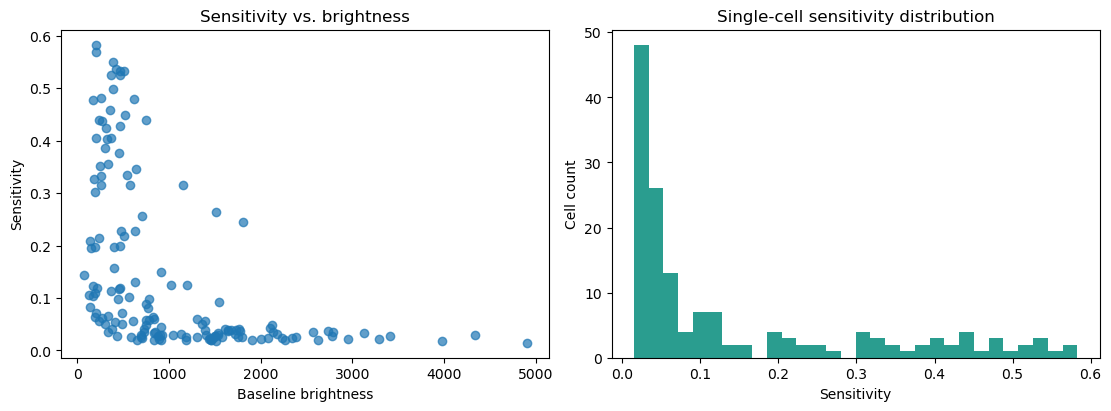

In [18]:
PEAK_WINDOW = 10
if len(peak_indices) == 0:
    raise RuntimeError("没有检测到刺激事件，请先检查平均轨迹和峰值参数。")

event_responses = np.empty((len(cell_ids), len(peak_indices)), dtype=np.float32)
for k, peak in enumerate(peak_indices):
    left = max(0, peak - PEAK_WINDOW)
    right = min(len(cell_normalized), peak + PEAK_WINDOW + 1)
    event_responses[:, k] = 1 - cell_normalized[left:right].min(axis=0)

response_mean = event_responses.mean(axis=1)
response_std = event_responses.std(axis=1)
within_range = np.abs(event_responses - response_mean[:, None]) <= 1.5 * response_std[:, None]
filtered_responses = np.where(within_range, event_responses, np.nan)
sensitivity = np.nanmean(filtered_responses, axis=1)

cell_results = pd.DataFrame({
    "cell_id": cell_ids,
    "area_pixels": cell_areas,
    "baseline_brightness": baseline,
    "sensitivity": sensitivity,
    "response_std": np.nanstd(filtered_responses, axis=1),
    "valid_events": np.isfinite(filtered_responses).sum(axis=1),
    "pass_basic_qc": quality_mask,
})
display(cell_results.head())

qualified = cell_results[cell_results["pass_basic_qc"]]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].scatter(qualified["baseline_brightness"], qualified["sensitivity"], alpha=0.7)
axes[0].set(xlabel="Baseline brightness", ylabel="Sensitivity", title="Sensitivity vs. brightness")
axes[1].hist(qualified["sensitivity"], bins=30, color="#2A9D8F")
axes[1].set(xlabel="Sensitivity", ylabel="Cell count", title="Single-cell sensitivity distribution")
plt.show()

**<font color="green"> TODO：检查单细胞信号分析结果 </font>**<br>

1. 比较原始细胞轨迹、局部背景轨迹和校正后轨迹。背景校正是否保留了刺激响应，同时减少了缓慢漂移？
2. 检查自动检测到的刺激事件数量和间距。它们是否与平均轨迹中的下降响应一致？若不一致，应优先调整`MIN_PEAK_PROMINENCE`还是`MIN_PEAK_DISTANCE`？
3. 观察灵敏度与基线亮度的散点图。低亮度细胞是否表现出更大的波动或异常灵敏度？
4. 从`cell_results`中选择一个高响应细胞和一个低响应细胞，绘制其标准化轨迹，并比较两者对各次刺激的响应。

## TASK 3



## Variants3 / field3

Result directory: /personal/result/Variants3/field3
Cellpose input: /personal/lab4/Variants3/field3/561-mCherry/average_projection_sharpened_bin4.tif
Movie input: /personal/lab4/Variants3/field3/561-mCherry/movie_bin4.bin
raw sharpened image shape: (256, 512)


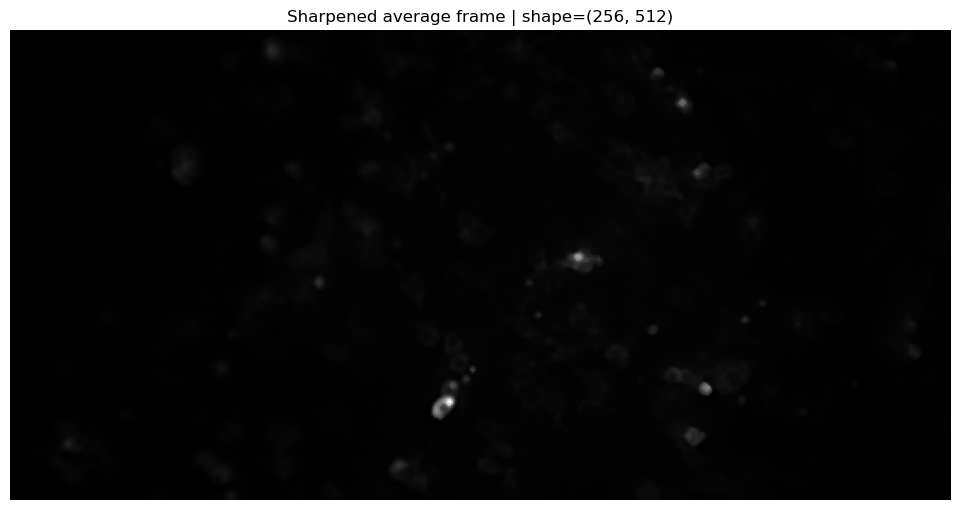

shape: (256, 512)
dtype: uint16
min: 0
max: 27162
mean: 321.74791717529297
median: 219.0
std: 563.6810348783323


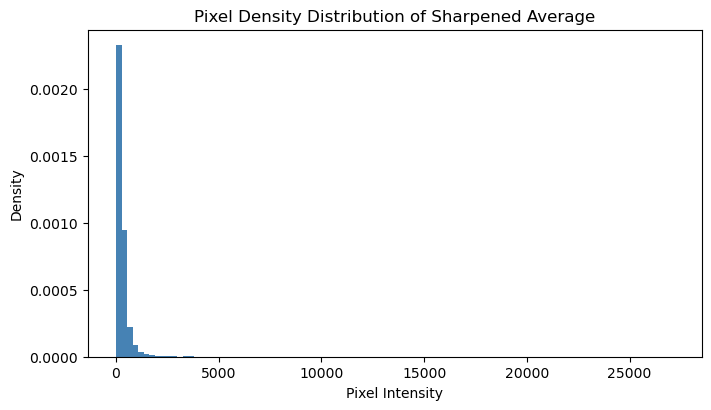

Cellpose masks before brightness QC: 95
Background brightness: 270.94
Brightness threshold: 596.07 (2.2x background)
Removed by brightness QC: 39
Detected cells after brightness QC: 56
Inference time: 2.03 s on Tesla T4
Mask area median: 94.0 pixels
Mask area range: 52?219 pixels


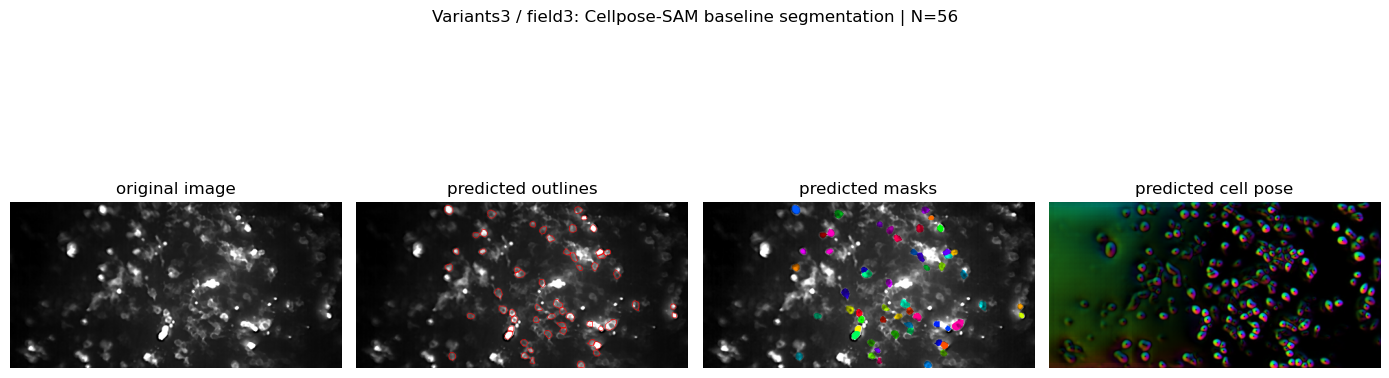

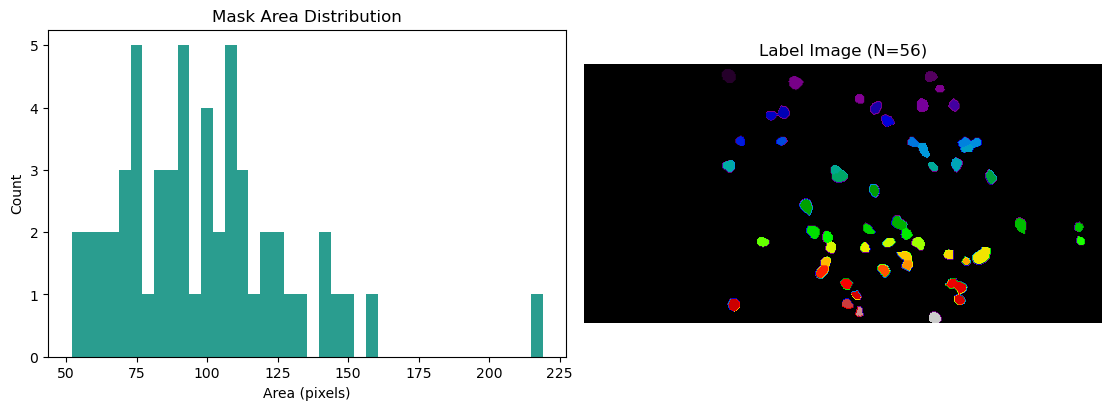

movie shape: (720, 256, 512)
analysis movie shape: (600, 256, 512)
analysis duration: 3.052 s
cell traces shape: (600, 56)
number of cells: 56


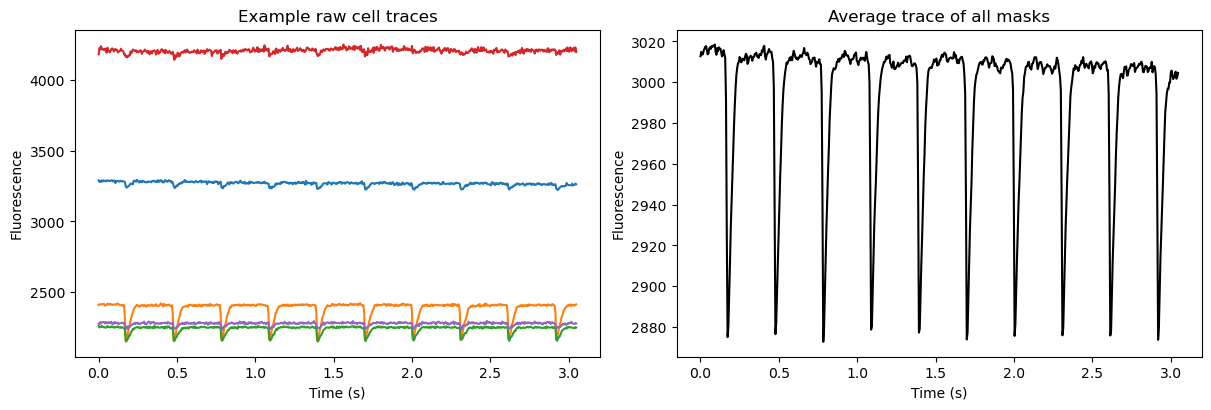

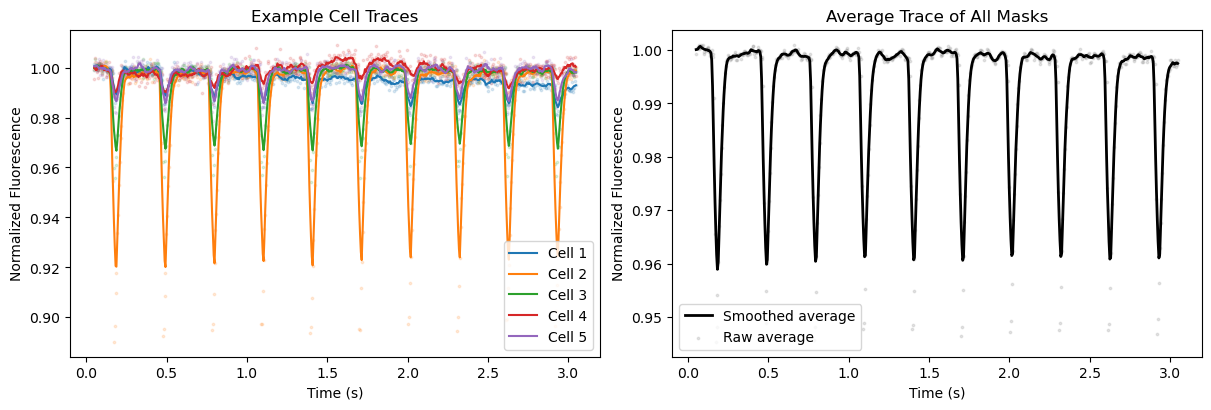

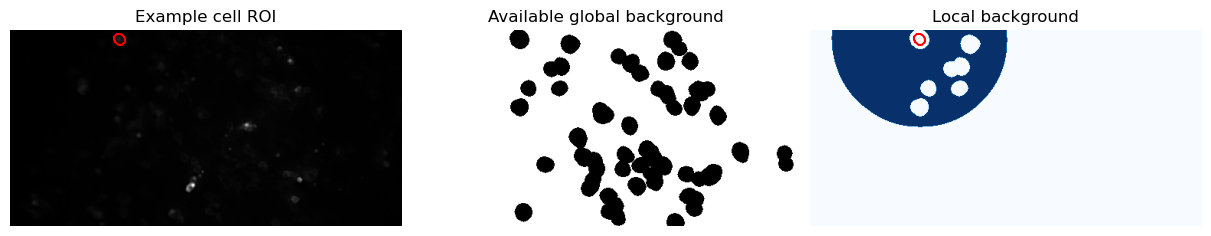

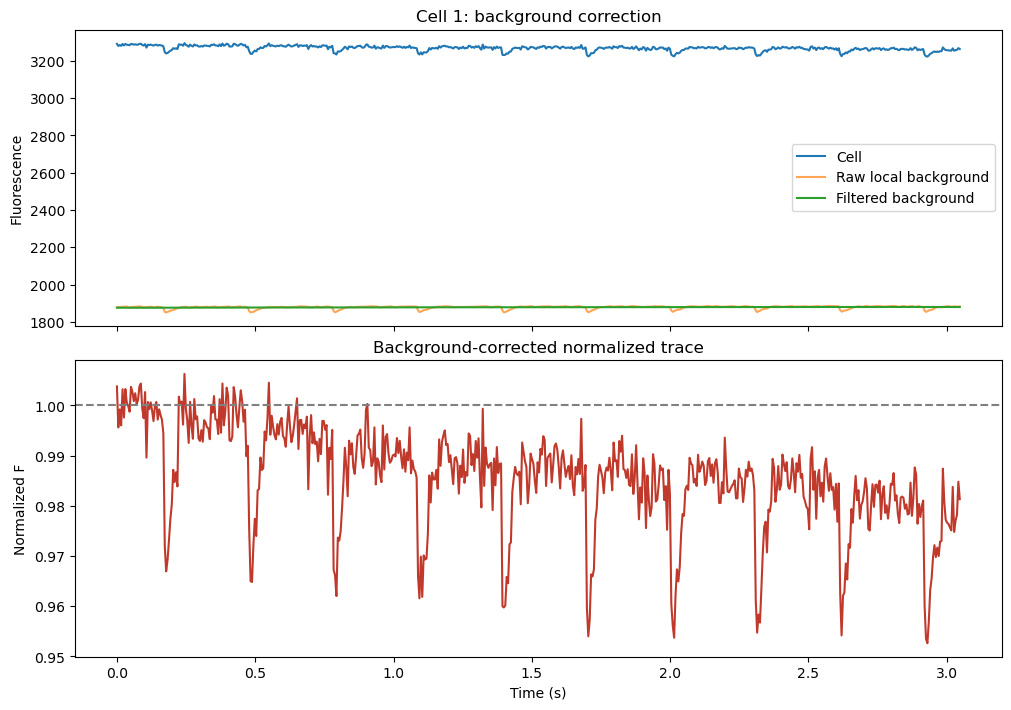

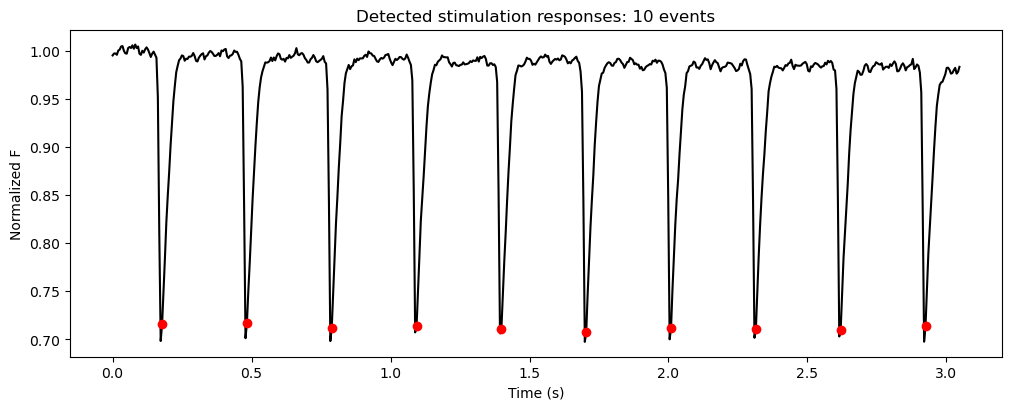

peak frames: [65, 125, 185, 245, 305, 365, 425, 485, 545, 605]
peak times in analysis window (s): [0.178, 0.483, 0.788, 1.094, 1.399, 1.704, 2.009, 2.314, 2.62, 2.925]


,cell_id,area_pixels,baseline_brightness,sensitivity,response_std,valid_events,pass_basic_qc
0,1,157,1410.630317,0.042498,0.004276,9,True
1,2,111,464.657451,0.553182,0.007224,8,True
2,3,140,320.186623,0.314613,0.005190,8,True
3,4,55,2238.757208,0.022280,0.002940,8,True
4,5,70,234.112574,0.184574,0.008215,8,True


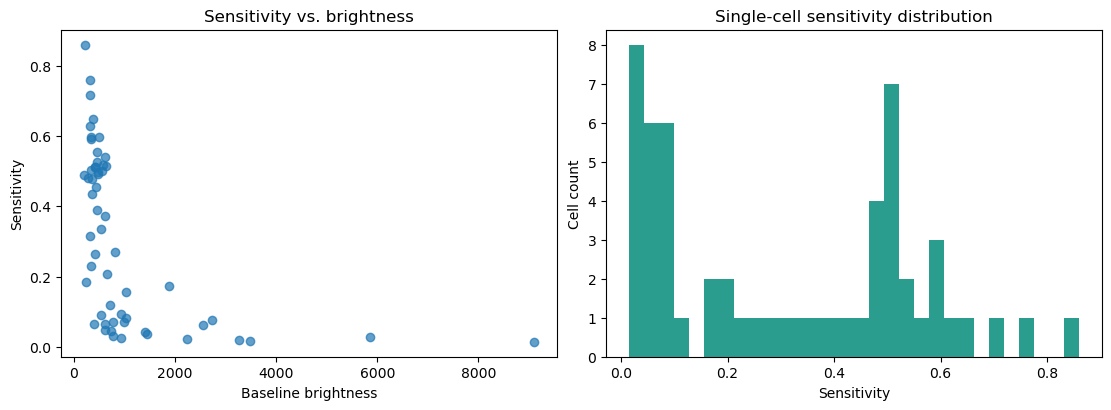

,variant,field,detected_cells,qc_cells,events,mean_sensitivity,result_dir
0,Variants3,field3,56,56,10,0.311041,/personal/result/Variants3/field3


215

In [19]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from cellpose import io, models, plot
from scipy.ndimage import distance_transform_edt, uniform_filter1d
from scipy.signal import butter, find_peaks, sosfiltfilt


def extract_mean_traces(movie_view, region_masks, chunk_size=25):
    """????????????????????"""
    weights = region_masks.reshape(len(region_masks), -1).astype(np.float32)
    pixel_counts = weights.sum(axis=1)
    if np.any(pixel_counts == 0):
        raise ValueError("????????????")
    weights /= pixel_counts[:, None]

    traces = np.empty((len(movie_view), len(region_masks)), dtype=np.float32)
    for start in range(0, len(movie_view), chunk_size):
        stop = min(start + chunk_size, len(movie_view))
        frames = np.asarray(movie_view[start:stop], dtype=np.float32)
        traces[start:stop] = frames.reshape(stop - start, -1) @ weights.T
    return traces


def save_figure(fig, output_path):
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def write_text(output_path, lines):
    output_path.write_text("".join(lines) + "", encoding="utf-8")


USE_GPU = torch.cuda.is_available()
DEVICE = torch.cuda.get_device_name(0) if USE_GPU else "CPU"
model = models.CellposeModel(gpu=USE_GPU)

CELLPOSE_PARAMS = {
    "diameter": None,
    "cellprob_threshold": 0.0,
    "flow_threshold": 0.4,
    "min_size": 15,
}
FPS = 196.5967
N_ROWS, N_COLS, TOTAL_FRAMES = 256, 512, 720
FRAME_START = 30
FRAME_STOP = 630
CELL_EXCLUSION_DISTANCE = 6
LOCAL_BACKGROUND_RADIUS = 108
NOTCH_RANGE = (2.5, 3.5)
SMOOTH_WINDOW = 181
BASELINE_FRAMES = 30
MIN_CELL_AREA = 15
MIN_PEAK_PROMINENCE = 0.025
MIN_PEAK_DISTANCE = 15
PEAK_WINDOW = 10

upload_root = Path("/personal/lab4")
result_root = Path("/personal/result")
MIN_CELL_TO_BACKGROUND_RATIO = 2.2
field_dirs = [
    upload_root / f"Variants{variant_idx}" / f"field{field_idx}" / "561-mCherry"
    for variant_idx in range(8)
    for field_idx in range(1, 5)
]

missing_dirs = [field_dir for field_dir in field_dirs if not field_dir.exists()]
if missing_dirs:
    missing_preview = "".join(str(missing_dir) for missing_dir in missing_dirs[:5])
    raise FileNotFoundError(f"Missing field directories:{missing_preview}")

summary_rows = []
all_results = {}

for field_dir in field_dirs:
    variant_name = field_dir.parent.parent.name
    field_name = field_dir.parent.name
    field_result_dir = result_root / variant_name / field_name
    field_result_dir.mkdir(parents=True, exist_ok=True)
    log_lines = []

    def log(*parts):
        message = " ".join(str(part) for part in parts)
        print(message)
        log_lines.append(message)

    sharpened_path = field_dir / "average_projection_sharpened_bin4.tif"
    movie_path = field_dir / "movie_bin4.bin"
    if not sharpened_path.exists() or not movie_path.exists():
        raise FileNotFoundError(
            f"Missing average_projection_sharpened_bin4.tif or movie_bin4.bin in {field_dir}"
        )

    display(Markdown(f"## {variant_name} / {field_name}"))
    log("Result directory:", field_result_dir)
    log("Cellpose input:", sharpened_path)
    log("Movie input:", movie_path)

    image = io.imread(str(sharpened_path))
    log("raw sharpened image shape:", image.shape)
    if image.shape == (N_COLS, N_ROWS):
        image = image.T
        log("transpose sharpened image to match movie frame orientation ->", image.shape)
    elif image.shape != (N_ROWS, N_COLS):
        raise ValueError(
            f"Unexpected sharpened image shape {image.shape}; expected {(N_ROWS, N_COLS)} or {(N_COLS, N_ROWS)}."
        )

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Sharpened average frame | shape={image.shape}")
    ax.axis("off")
    save_figure(fig, field_result_dir / "01_sharpened_average.png")

    log("shape:", image.shape)
    log("dtype:", image.dtype)
    log("min:", int(image.min()))
    log("max:", int(image.max()))
    log("mean:", float(image.mean()))
    log("median:", float(np.median(image)))
    log("std:", float(image.std()))

    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    ax.hist(image.ravel(), bins=100, density=True, color="steelblue")
    ax.set_title("Pixel Density Distribution of Sharpened Average")
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Density")
    save_figure(fig, field_result_dir / "02_pixel_hist.png")

    start = time.perf_counter()
    result = model.eval(image, **CELLPOSE_PARAMS)
    elapsed = time.perf_counter() - start

    if len(result) == 3:
        masks, flows, styles = result
    elif len(result) == 4:
        masks, flows, styles, _ = result
    else:
        raise RuntimeError(f"??? Cellpose ?????{len(result)} ?")

    raw_cell_count = int(masks.max())
    background_pixels = image[masks == 0]
    if background_pixels.size == 0:
        raise RuntimeError("No unsegmented pixels are available to estimate background brightness.")

    background_brightness = float(background_pixels.mean())
    cell_ids_before_brightness_qc = np.arange(1, raw_cell_count + 1)
    cell_brightness = np.array([
        image[masks == cell_id].mean()
        for cell_id in cell_ids_before_brightness_qc
    ])
    brightness_threshold = MIN_CELL_TO_BACKGROUND_RATIO * background_brightness
    retained_cell_ids = cell_ids_before_brightness_qc[
        cell_brightness >= brightness_threshold
    ]

    filtered_masks = np.zeros_like(masks)
    for new_cell_id, old_cell_id in enumerate(retained_cell_ids, start=1):
        filtered_masks[masks == old_cell_id] = new_cell_id
    masks = filtered_masks

    cell_count = int(masks.max())
    areas = np.bincount(masks.ravel())[1:]
    log(f"Cellpose masks before brightness QC: {raw_cell_count}")
    log(f"Background brightness: {background_brightness:.2f}")
    log(f"Brightness threshold: {brightness_threshold:.2f} ({MIN_CELL_TO_BACKGROUND_RATIO:.1f}x background)")
    log(f"Removed by brightness QC: {raw_cell_count - cell_count}")
    log(f"Detected cells after brightness QC: {cell_count}")
    log(f"Inference time: {elapsed:.2f} s on {DEVICE}")
    if areas.size:
        log(f"Mask area median: {np.median(areas):.1f} pixels")
        log(f"Mask area range: {int(areas.min())}?{int(areas.max())} pixels")

    fig = plt.figure(figsize=(14, 5))
    plot.show_segmentation(fig, image, masks, flows[0])
    fig.suptitle(
        f"{variant_name} / {field_name}: Cellpose-SAM baseline segmentation | N={cell_count}",
        y=1.02,
    )
    fig.tight_layout()
    save_figure(fig, field_result_dir / "03_segmentation.png")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    axes[0].hist(areas, bins=40, color="#2A9D8F")
    axes[0].set(title="Mask Area Distribution", xlabel="Area (pixels)", ylabel="Count")
    axes[1].imshow(masks, cmap="nipy_spectral")
    axes[1].set_title(f"Label Image (N={cell_count})")
    axes[1].axis("off")
    save_figure(fig, field_result_dir / "04_mask_area_and_labels.png")

    raw_movie = np.memmap(movie_path, dtype="<u2", mode="r")
    expected_pixels = TOTAL_FRAMES * N_ROWS * N_COLS
    assert raw_movie.size == expected_pixels, (
        f"??????{raw_movie.size}????{expected_pixels}???????movie shape?"
    )

    movie = raw_movie.reshape(TOTAL_FRAMES, N_COLS, N_ROWS).transpose(0, 2, 1)
    analysis_movie = movie[FRAME_START:FRAME_STOP]
    time_axis = np.arange(analysis_movie.shape[0]) / FPS

    assert movie.shape == (TOTAL_FRAMES, N_ROWS, N_COLS)
    if image.shape != movie.shape[1:]:
        raise ValueError(
            f"Image shape {image.shape} does not match movie frame shape {movie.shape[1:]}."
        )

    log("movie shape:", movie.shape)
    log("analysis movie shape:", analysis_movie.shape)
    log(f"analysis duration: {analysis_movie.shape[0] / FPS:.3f} s")

    cell_ids = np.arange(1, cell_count + 1)
    roi_masks = np.stack([masks == cell_id for cell_id in cell_ids])
    cell_areas = roi_masks.sum(axis=(1, 2))
    cell_traces = extract_mean_traces(analysis_movie, roi_masks)
    log("cell traces shape:", cell_traces.shape)
    log("number of cells:", len(cell_ids))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    axes[0].plot(time_axis, cell_traces[:, :min(5, len(cell_ids))])
    axes[0].set(title="Example raw cell traces", xlabel="Time (s)", ylabel="Fluorescence")
    axes[1].plot(time_axis, cell_traces.mean(axis=1), color="black")
    axes[1].set(title="Average trace of all masks", xlabel="Time (s)", ylabel="Fluorescence")
    save_figure(fig, field_result_dir / "05_raw_traces.png")

    display_start = 10
    example_cells = range(min(5, cell_traces.shape[1]))
    trace_baseline = cell_traces[:30].mean(axis=0)
    normalized_traces = cell_traces / trace_baseline
    smoothed_traces = uniform_filter1d(normalized_traces, size=7, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    for cell in example_cells:
        axes[0].scatter(
            time_axis[display_start:],
            normalized_traces[display_start:, cell],
            s=3,
            alpha=0.15,
        )
        axes[0].plot(
            time_axis[display_start:],
            smoothed_traces[display_start:, cell],
            linewidth=1.5,
            label=f"Cell {cell + 1}",
        )
    axes[0].set(
        title="Example Cell Traces",
        xlabel="Time (s)",
        ylabel="Normalized Fluorescence",
    )
    axes[0].legend()

    average_trace = normalized_traces.mean(axis=1)
    average_smoothed = uniform_filter1d(average_trace, size=7)
    axes[1].scatter(
        time_axis[display_start:],
        average_trace[display_start:],
        s=3,
        color="gray",
        alpha=0.2,
        label="Raw average",
    )
    axes[1].plot(
        time_axis[display_start:],
        average_smoothed[display_start:],
        color="black",
        linewidth=2,
        label="Smoothed average",
    )
    axes[1].set(
        title="Average Trace of All Masks",
        xlabel="Time (s)",
        ylabel="Normalized Fluorescence",
    )
    axes[1].legend()
    save_figure(fig, field_result_dir / "06_normalized_traces.png")

    distance_from_any_cell = distance_transform_edt(masks == 0)
    global_background = distance_from_any_cell > CELL_EXCLUSION_DISTANCE
    local_background_masks = np.empty_like(roi_masks)
    for i, roi_mask in enumerate(roi_masks):
        distance_from_cell = distance_transform_edt(~roi_mask)
        local_background_masks[i] = global_background & (distance_from_cell <= LOCAL_BACKGROUND_RADIUS)

    background_traces = extract_mean_traces(analysis_movie, local_background_masks)

    example_cell = 0
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    axes[0].imshow(image, cmap="gray")
    axes[0].contour(roi_masks[example_cell], colors="red", linewidths=0.8)
    axes[0].set_title("Example cell ROI")
    axes[1].imshow(global_background, cmap="gray")
    axes[1].set_title("Available global background")
    axes[2].imshow(local_background_masks[example_cell], cmap="Blues")
    axes[2].contour(roi_masks[example_cell], colors="red", linewidths=0.8)
    axes[2].set_title("Local background")
    for ax in axes:
        ax.axis("off")
    save_figure(fig, field_result_dir / "07_background_masks.png")

    sos = butter(2, NOTCH_RANGE, btype="bandstop", fs=FPS, output="sos")
    background_notched = sosfiltfilt(sos, background_traces, axis=0)
    background_filtered = uniform_filter1d(
        background_notched, size=SMOOTH_WINDOW, axis=0, mode="nearest"
    )

    cell_corrected = cell_traces - background_filtered
    baseline = cell_corrected[:BASELINE_FRAMES].mean(axis=0)
    cell_normalized = cell_corrected / baseline

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
    axes[0].plot(time_axis, cell_traces[:, example_cell], label="Cell")
    axes[0].plot(time_axis, background_traces[:, example_cell], label="Raw local background", alpha=0.7)
    axes[0].plot(time_axis, background_filtered[:, example_cell], label="Filtered background")
    axes[0].set(ylabel="Fluorescence", title=f"Cell {cell_ids[example_cell]}: background correction")
    axes[0].legend()
    axes[1].plot(time_axis, cell_normalized[:, example_cell], color="#C0392B")
    axes[1].axhline(1, color="gray", linestyle="--")
    axes[1].set(xlabel="Time (s)", ylabel="Normalized F", title="Background-corrected normalized trace")
    save_figure(fig, field_result_dir / "08_background_correction.png")

    quality_mask = (cell_areas >= MIN_CELL_AREA) & np.isfinite(baseline) & (baseline > 0)
    if not np.any(quality_mask):
        raise RuntimeError(f"{variant_name} / {field_name} ???????????")

    global_trace = cell_normalized[:, quality_mask].mean(axis=1)
    peak_signal = uniform_filter1d(1 - global_trace, size=3)
    peak_indices, peak_properties = find_peaks(
        peak_signal,
        prominence=MIN_PEAK_PROMINENCE,
        distance=MIN_PEAK_DISTANCE,
    )

    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    ax.plot(time_axis, global_trace, color="black")
    ax.scatter(time_axis[peak_indices], global_trace[peak_indices], color="red", zorder=3)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Normalized F")
    ax.set_title(f"Detected stimulation responses: {len(peak_indices)} events")
    save_figure(fig, field_result_dir / "09_detected_events.png")

    log("peak frames:", (peak_indices + FRAME_START).tolist())
    log("peak times in analysis window (s):", np.round(time_axis[peak_indices], 3).tolist())

    if len(peak_indices) == 0:
        raise RuntimeError(f"{variant_name} / {field_name} ??????????????????")

    event_responses = np.empty((len(cell_ids), len(peak_indices)), dtype=np.float32)
    for k, peak in enumerate(peak_indices):
        left = max(0, peak - PEAK_WINDOW)
        right = min(len(cell_normalized), peak + PEAK_WINDOW + 1)
        event_responses[:, k] = 1 - cell_normalized[left:right].min(axis=0)

    response_mean = event_responses.mean(axis=1)
    response_std = event_responses.std(axis=1)
    within_range = np.abs(event_responses - response_mean[:, None]) <= 1.5 * response_std[:, None]
    filtered_responses = np.where(within_range, event_responses, np.nan)
    sensitivity = np.nanmean(filtered_responses, axis=1)

    cell_results = pd.DataFrame({
        "cell_id": cell_ids,
        "area_pixels": cell_areas,
        "baseline_brightness": baseline,
        "sensitivity": sensitivity,
        "response_std": np.nanstd(filtered_responses, axis=1),
        "valid_events": np.isfinite(filtered_responses).sum(axis=1),
        "pass_basic_qc": quality_mask,
    })
    display(cell_results.head())

    qualified = cell_results[cell_results["pass_basic_qc"]]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    axes[0].scatter(qualified["baseline_brightness"], qualified["sensitivity"], alpha=0.7)
    axes[0].set(xlabel="Baseline brightness", ylabel="Sensitivity", title="Sensitivity vs. brightness")
    axes[1].hist(qualified["sensitivity"], bins=30, color="#2A9D8F")
    axes[1].set(xlabel="Sensitivity", ylabel="Cell count", title="Single-cell sensitivity distribution")
    save_figure(fig, field_result_dir / "10_sensitivity_summary.png")

    cell_results.to_csv(field_result_dir / "cell_results.csv", index=False)
    qualified.to_csv(field_result_dir / "qualified_cell_results.csv", index=False)
    pd.DataFrame({
        "peak_frame": peak_indices + FRAME_START,
        "peak_time_s": np.round(time_axis[peak_indices], 6),
        "prominence": peak_properties.get("prominences", np.array([], dtype=float)),
    }).to_csv(field_result_dir / "detected_events.csv", index=False)

    np.save(field_result_dir / "image.npy", image)
    np.save(field_result_dir / "masks.npy", masks)
    np.save(field_result_dir / "cell_areas.npy", cell_areas)
    np.save(field_result_dir / "time_axis.npy", time_axis)
    np.save(field_result_dir / "cell_traces.npy", cell_traces)
    np.save(field_result_dir / "normalized_traces.npy", normalized_traces)
    np.save(field_result_dir / "background_traces.npy", background_traces)
    np.save(field_result_dir / "background_filtered.npy", background_filtered)
    np.save(field_result_dir / "cell_corrected.npy", cell_corrected)
    np.save(field_result_dir / "cell_normalized.npy", cell_normalized)
    np.save(field_result_dir / "global_trace.npy", global_trace)
    np.save(field_result_dir / "event_responses.npy", event_responses)
    np.save(field_result_dir / "filtered_responses.npy", filtered_responses)
    np.save(field_result_dir / "roi_masks.npy", roi_masks)
    np.save(field_result_dir / "local_background_masks.npy", local_background_masks)

    metadata = {
        "variant": variant_name,
        "field": field_name,
        "result_dir": str(field_result_dir),
        "input_image": str(sharpened_path),
        "input_movie": str(movie_path),
        "detected_cells": cell_count,
        "qc_cells": int(quality_mask.sum()),
        "events": int(len(peak_indices)),
        "mean_sensitivity": float(np.nanmean(qualified["sensitivity"])) if len(qualified) else None,
        "cellpose_params": CELLPOSE_PARAMS,
        "fps": FPS,
        "frame_start": FRAME_START,
        "frame_stop": FRAME_STOP,
    }
    (field_result_dir / "metadata.json").write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    write_text(field_result_dir / "log.txt", log_lines)

    summary_rows.append({
        "variant": variant_name,
        "field": field_name,
        "detected_cells": cell_count,
        "qc_cells": int(quality_mask.sum()),
        "events": len(peak_indices),
        "mean_sensitivity": float(np.nanmean(qualified["sensitivity"])) if len(qualified) else np.nan,
        "result_dir": str(field_result_dir),
    })
    all_results[(variant_name, field_name)] = {
        "result_dir": field_result_dir,
        "cell_results": cell_results,
        "qualified": qualified,
        "metadata": metadata,
    }

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(result_root / "summary.csv", index=False)
(result_root / "summary.json").write_text(
    summary_df.to_json(orient="records", force_ascii=False, indent=2),
    encoding="utf-8",
)


### task 3.1



,variant,field,cell_id,baseline_brightness,sensitivity,selected_rank,selected_fraction
0,Variants0,field1,82,384.679422,0.554539,1,0.330882
1,Variants0,field1,43,414.812825,0.541713,2,0.330882
2,Variants0,field1,28,502.511780,0.537955,3,0.330882
3,Variants0,field1,80,460.188698,0.537768,4,0.330882
4,Variants0,field1,40,466.388484,0.530632,5,0.330882
...,...,...,...,...,...,...,...
957,Variants7,field4,40,179.132459,0.467553,20,0.342857
958,Variants7,field4,16,177.469467,0.464114,21,0.342857
959,Variants7,field4,30,448.428413,0.456084,22,0.342857
960,Variants7,field4,37,367.509332,0.452533,23,0.342857


,variant,cell_count,mean_sensitivity,variance_sensitivity
0,Variants0,170,0.331997,0.028624
1,Variants1,119,0.443638,0.012133
2,Variants2,115,0.386982,0.025412
3,Variants3,100,0.451256,0.015735
4,Variants4,129,0.480918,0.008054
5,Variants5,110,0.258194,0.023725
6,Variants6,109,0.454757,0.005004
7,Variants7,110,0.445005,0.012383


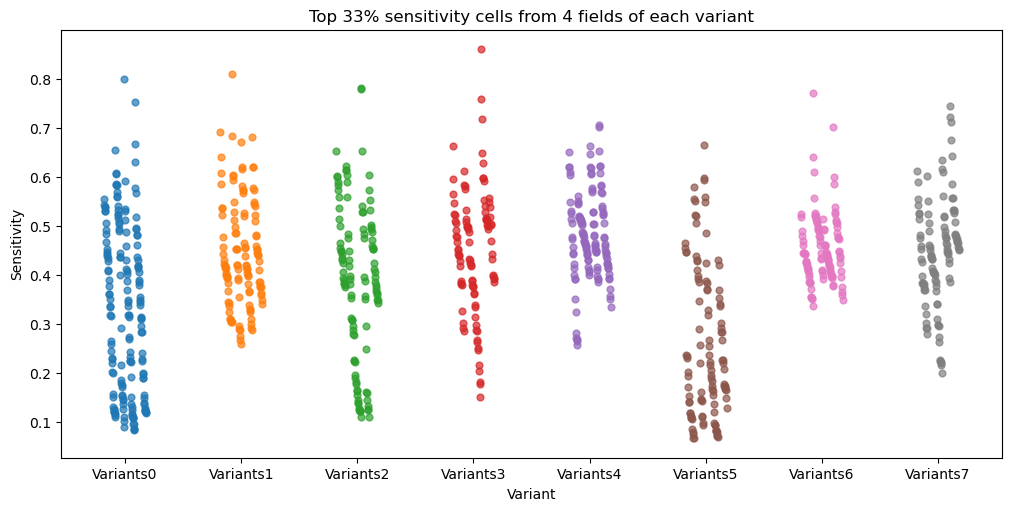

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


result_root = Path("/personal/result")
variant_names = [f"Variants{i}" for i in range(8)]
field_names = [f"field{i}" for i in range(1, 5)]

selected_rows = []
missing_files = []

for variant_name in variant_names:
    for field_name in field_names:
        csv_path = result_root / variant_name / field_name / "qualified_cell_results.csv"
        if not csv_path.exists():
            missing_files.append(str(csv_path))
            continue

        field_df = pd.read_csv(csv_path)
        field_df = field_df[np.isfinite(field_df["sensitivity"])].copy()
        if field_df.empty:
            continue

        top_count = max(1, int(np.ceil(len(field_df) * 0.33)))
        top_df = field_df.nlargest(top_count, "sensitivity").copy()
        top_df["variant"] = variant_name
        top_df["field"] = field_name
        top_df["selected_rank"] = np.arange(1, len(top_df) + 1)
        top_df["selected_fraction"] = top_count / len(field_df)
        selected_rows.append(top_df)

if missing_files:
    preview = "\n".join(missing_files[:5])
    print(f"Missing result files (showing up to 5):\n{preview}")

if not selected_rows:
    raise RuntimeError("No qualified_cell_results.csv data found under /personal/result.")

selected_cells = pd.concat(selected_rows, ignore_index=True)
selected_cells["variant_index"] = selected_cells["variant"].str.replace("Variants", "", regex=False).astype(int)

variant_stats = (
    selected_cells.groupby("variant", sort=True)["sensitivity"]
    .agg(cell_count="size", mean_sensitivity="mean", variance_sensitivity="var")
    .reset_index()
)
variant_stats["variance_sensitivity"] = variant_stats["variance_sensitivity"].fillna(0.0)
variant_stats["variant_index"] = variant_stats["variant"].str.replace("Variants", "", regex=False).astype(int)
variant_stats = variant_stats.sort_values("variant_index").reset_index(drop=True)

selected_cells = selected_cells.sort_values(["variant_index", "field", "sensitivity"], ascending=[True, True, False]).reset_index(drop=True)
display(selected_cells[["variant", "field", "cell_id", "baseline_brightness", "sensitivity", "selected_rank", "selected_fraction"]])
display(variant_stats[["variant", "cell_count", "mean_sensitivity", "variance_sensitivity"]])

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for variant_idx, variant_name in enumerate(variant_names):
    variant_points = selected_cells[selected_cells["variant"] == variant_name]
    if variant_points.empty:
        continue
    offsets = np.linspace(-0.18, 0.18, len(variant_points)) if len(variant_points) > 1 else np.array([0.0])
    ax.scatter(
        variant_idx + offsets,
        variant_points["sensitivity"],
        alpha=0.7,
        s=24,
        label=variant_name if variant_idx == 0 else None,
    )

ax.set_xticks(range(len(variant_names)))
ax.set_xticklabels(variant_names, rotation=0)
ax.set_xlabel("Variant")
ax.set_ylabel("Sensitivity")
ax.set_title("Top 33% sensitivity cells from 4 fields of each variant")
plt.show()


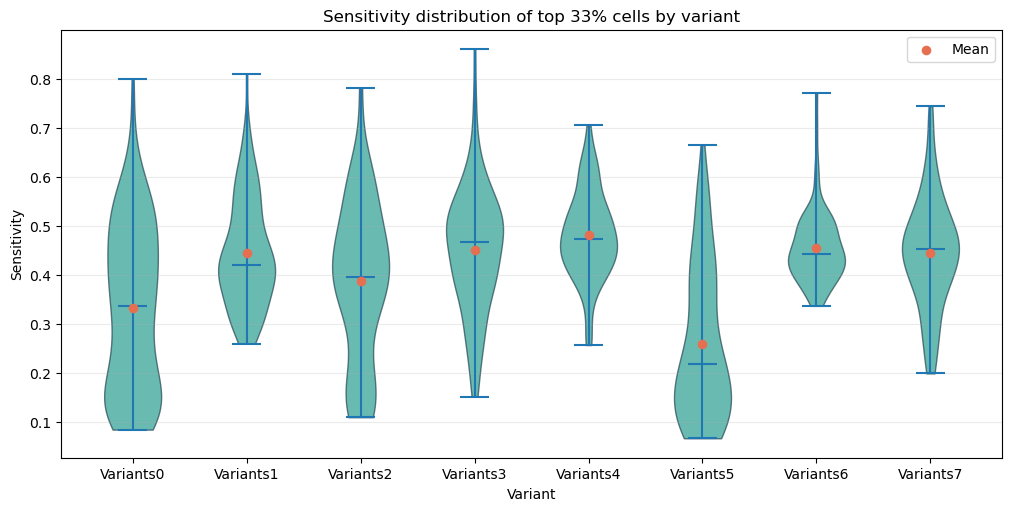

In [21]:
# Task 3.1: 绘制各 variant 的 top 33% 细胞灵敏度小提琴图
violin_data = [
    selected_cells.loc[selected_cells["variant"] == variant_name, "sensitivity"].dropna().to_numpy()
    for variant_name in variant_names
]

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
valid_positions = [i + 1 for i, values in enumerate(violin_data) if len(values) > 0]
valid_data = [values for values in violin_data if len(values) > 0]
if valid_data:
    parts = ax.violinplot(
        valid_data,
        positions=valid_positions,
        showmeans=False,
        showmedians=True,
        showextrema=True,
    )
    for body in parts["bodies"]:
        body.set_facecolor("#2A9D8F")
        body.set_edgecolor("#264653")
        body.set_alpha(0.7)
    means = [np.mean(values) for values in valid_data]
    ax.scatter(valid_positions, means, color="#E76F51", marker="o", s=35, zorder=3, label="Mean")

ax.set_xticks(range(1, len(variant_names) + 1))
ax.set_xticklabels(variant_names)
ax.set_xlabel("Variant")
ax.set_ylabel("Sensitivity")
ax.set_title("Sensitivity distribution of top 33% cells by variant")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()
